In [27]:
# Cell 1: Setup & Smart Data Loading (Checks Parent Folder)
import sys
import subprocess
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Auto-Install Seaborn (if missing)
try:
    import seaborn as sns
    print("✅ Seaborn is ready!")
except ImportError:
    print("⚠️ Installing Seaborn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Define File Name
filename = 'puerto_rico_master_profile_2010_2024.csv'

# 3. Smart Search (Current Folder vs. Parent Folder)
if os.path.exists(filename):
    # Case A: File is right here
    df = pd.read_csv(filename)
    print(f"✅ Found file in Current Directory!")
elif os.path.exists(f"../{filename}"):
    # Case B: File is one folder up (Your scenario)
    df = pd.read_csv(f"../{filename}")
    print(f"✅ Found file in Parent Directory (../{filename})")
else:
    # Case C: Panic
    print(f"❌ ERROR: Could not find '{filename}' here or in the folder above.")
    print(f"   Current Folder: {os.getcwd()}")
    raise FileNotFoundError("File not found.")

print(f"✅ Data Loaded Successfully! ({len(df)} rows)")

# 4. Define Indicators
SVI_VARS = {
    "THEME1_SOCIO": ["pct_below_poverty", "unemployment_rate_pct", "median_income_real", "pct_no_hs_diploma"],
    "THEME2_HH_DIS": ["pct_aged_65_plus", "pct_aged_17_under", "pct_disability", "pct_single_parent"],
    "THEME3_MINORITY": ["pct_lim_english"], 
    "THEME4_HOUSING": ["pct_multi_unit", "pct_mobile_homes", "pct_crowding", "pct_no_vehicle", "pct_group_quarters"]
}
INVERT_VARS = ["median_income_real"]

print(f"Ready to analyze!")
df.head()

✅ Seaborn is ready!
✅ Found file in Parent Directory (../puerto_rico_master_profile_2010_2024.csv)
✅ Data Loaded Successfully! (1014 rows)
Ready to analyze!


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,unemployment_rate_pct,labor_force_participation_pct,median_income_nominal,...,pct_no_hs_diploma,pct_aged_65_plus,pct_aged_17_under,pct_disability,pct_single_parent,pct_lim_english,pct_multi_unit,pct_mobile_homes,pct_crowding,pct_group_quarters
0,2012,Adjuntas Municipio,72001,19458.0,0.0,15081.0,80.0,23.1,39.6,13095.0,...,20.1,51.8,69.2,21.9,2.83,7.3,1.9,0.0,1.1,0.37
1,2012,Aguada Municipio,72003,41876.0,0.0,33277.0,134.0,30.7,48.7,15106.0,...,19.2,51.4,71.4,28.9,2.32,15.1,1.3,0.0,0.6,0.23
2,2012,Aguadilla Municipio,72005,60714.0,0.0,48215.0,181.0,24.5,40.1,15302.0,...,28.8,52.4,71.9,21.9,2.69,20.1,6.8,0.2,0.6,2.44
3,2012,Aguas Buenas Municipio,72007,28573.0,0.0,22384.0,104.0,13.2,33.1,13994.0,...,15.8,51.8,70.5,22.8,1.68,6.0,1.5,0.4,0.5,0.70
4,2012,Aibonito Municipio,72009,25823.0,0.0,20332.0,86.0,10.0,36.9,16235.0,...,16.4,52.3,71.1,31.5,3.97,13.3,1.7,0.0,0.7,0.22


In [28]:
# Cell 2: SVI Calculation Logic
def calculate_svi_rankings(df):
    svi_df = df.copy()
    
    # 1. Indicators (Higher = More Vulnerable)
    # Note: We rank these within each year
    indicators = [
        'unemployment_rate_pct', 'pct_below_poverty', 'pct_no_hs_diploma',
        'pct_aged_65_plus', 'pct_aged_17_under', 'pct_disability', 
        'pct_single_parent', 'pct_no_vehicle', 'pct_crowding'
    ]
    
    # 2. Calculate Percentile Ranks
    for var in indicators:
        svi_df[f'R_{var}'] = svi_df.groupby('year')[var].rank(pct=True)
    
    # Invert Income (Lower Income = Higher Rank/Vulnerability)
    svi_df['R_income'] = svi_df.groupby('year')['median_income_real'].rank(pct=True, ascending=False)
    
    # 3. Aggregate into Overall Score
    rank_cols = [f'R_{v}' for v in indicators] + ['R_income']
    svi_df['SVI_SUM'] = svi_df[rank_cols].sum(axis=1)
    
    # 4. Final SVI Percentile (0 to 1.0)
    # We name it OVERALL_SVI to match the next cells
    svi_df['OVERALL_SVI'] = svi_df.groupby('year')['SVI_SUM'].rank(pct=True)
    
    return svi_df

svi_results = calculate_svi_rankings(df)
print("✅ SVI Percentiles calculated (2010-2024)")

✅ SVI Percentiles calculated (2010-2024)


In [29]:
# Cell 3: Styled Summary Table for 2024
import sys
import subprocess
from IPython.display import display

# Ensure jinja2 is installed for styling
try:
    import jinja2
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jinja2"])
    import jinja2

# Top 10 High-Vulnerability Towns in 2024
latest_year = 2024
summary = svi_results[svi_results['year'] == latest_year].sort_values('OVERALL_SVI', ascending=False).head(10)

# Display styled table
styled = summary[['municipio', 'OVERALL_SVI', 'pct_below_poverty', 'unemployment_rate_pct', 'pct_no_vehicle']]\
    .style.background_gradient(cmap='YlOrRd', subset=['OVERALL_SVI'])\
    .format({'OVERALL_SVI': '{:.4f}', 'pct_below_poverty': '{:.1f}%', 'unemployment_rate_pct': '{:.1f}%', 'pct_no_vehicle': '{:.1f}%'})\
    .hide(axis='index')

display(styled)

municipio,OVERALL_SVI,pct_below_poverty,unemployment_rate_pct,pct_no_vehicle
Maunabo Municipio,1.0000,54.6%,12.1%,17.1%
Ponce Municipio,0.9872,49.7%,15.1%,15.6%
Guánica Municipio,0.9744,63.6%,22.9%,10.8%
Comerío Municipio,0.9615,52.8%,15.3%,18.5%
Naranjito Municipio,0.9487,51.1%,11.7%,14.5%
San Sebastián Municipio,0.9359,49.7%,13.0%,9.6%
Salinas Municipio,0.9231,47.9%,7.2%,13.3%
Utuado Municipio,0.9103,50.3%,21.2%,12.4%
Juana Díaz Municipio,0.8974,44.1%,16.1%,12.6%
Lares Municipio,0.8846,55.4%,13.0%,12.3%


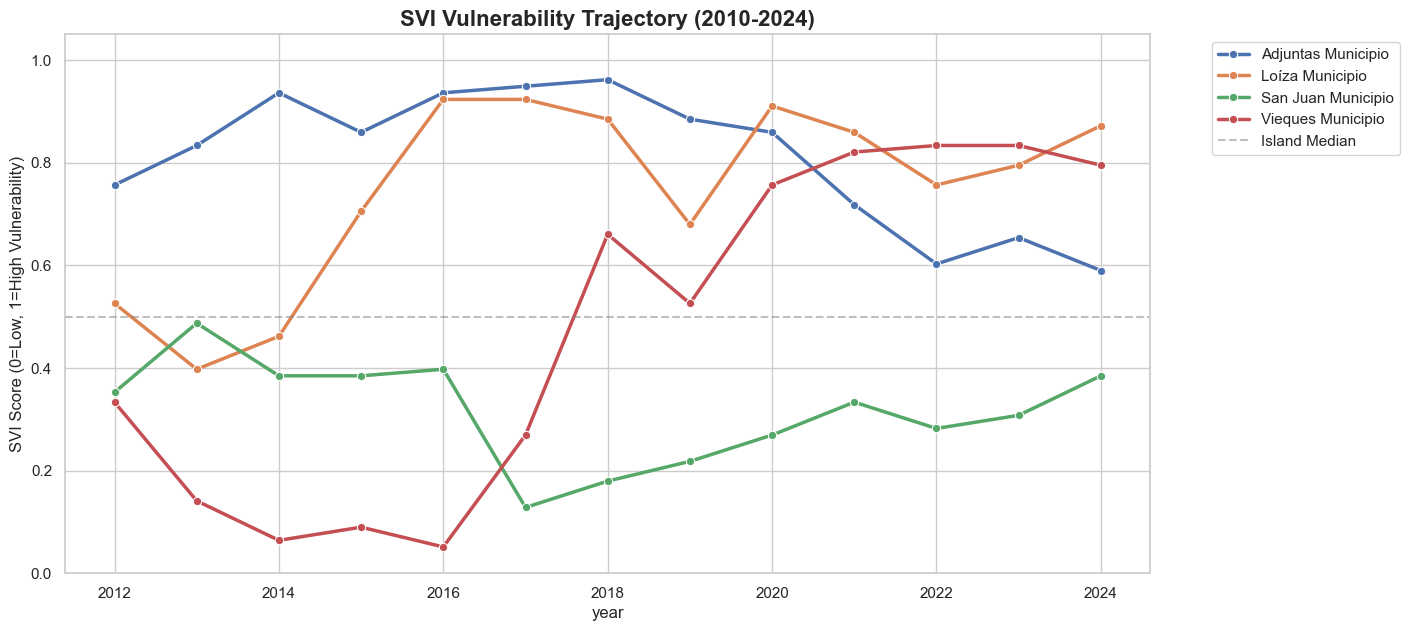

In [30]:
# Cell 4: Vulnerability Trend Analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Pick 4 towns for comparison
sample_towns = ["Adjuntas Municipio", "San Juan Municipio", "Vieques Municipio", "Loíza Municipio"]
plot_data = svi_results[svi_results['municipio'].isin(sample_towns)]

plt.figure(figsize=(14, 7))
# FIXED: Changed y="RPL_THEMES" to y="OVERALL_SVI"
sns.lineplot(data=plot_data, x="year", y="OVERALL_SVI", hue="municipio", marker="o", linewidth=2.5)

plt.title("SVI Vulnerability Trajectory (2010-2024)", fontsize=16, fontweight='bold')
plt.ylabel("SVI Score (0=Low, 1=High Vulnerability)", fontsize=12)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label="Island Median")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

📊 Analyzing change between 2012 and 2024...
🚨 TOP 10 MUNICIPALITIES WITH HIGHEST VULNERABILITY INCREASE (2012-2024)


year,SVI_Change
municipio,
San Germán Municipio,0.679487
Naranjito Municipio,0.641026
Coamo Municipio,0.551282
Vieques Municipio,0.461538
Comerío Municipio,0.371795
Loíza Municipio,0.346154
Juana Díaz Municipio,0.346154
Ponce Municipio,0.320513
Mayagüez Municipio,0.320513


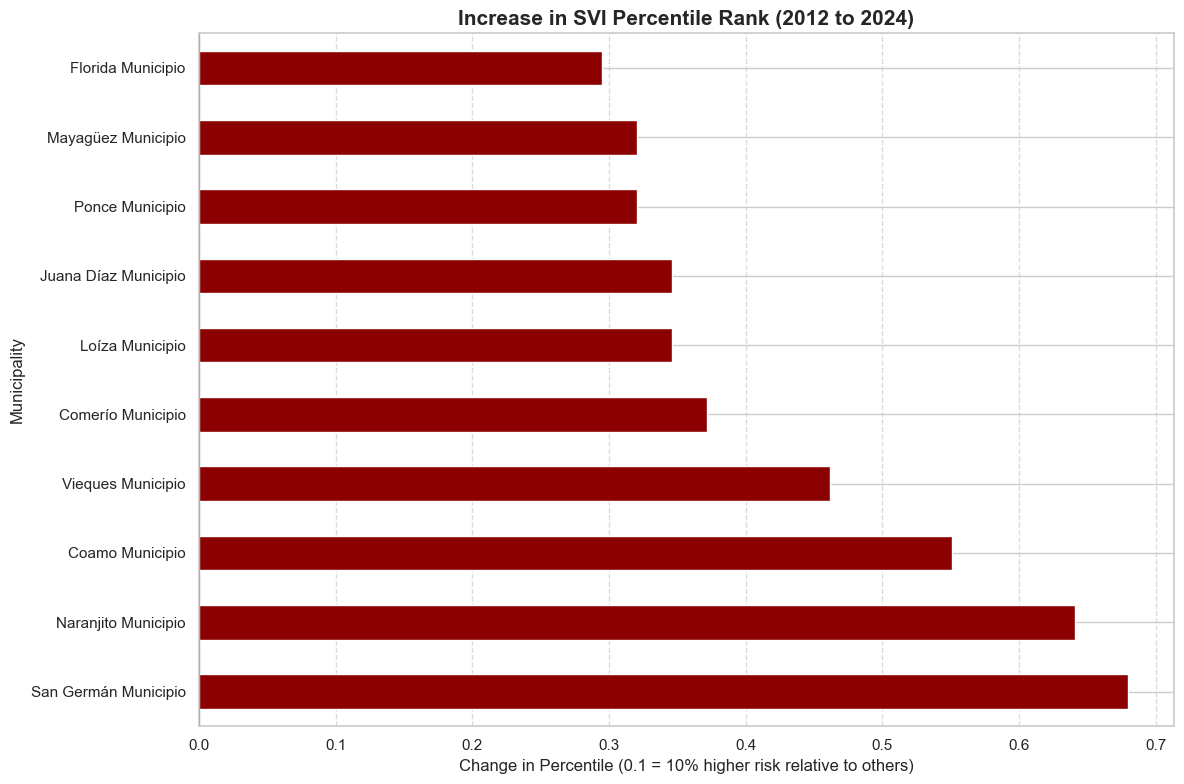

In [31]:
# Cell 5: Vulnerability Change Analysis (Automatic Year Detection)

# 1. Identify the earliest and latest years available in the data
years_available = sorted(svi_results['year'].unique())
first_year = years_available[0]
last_year = years_available[-1]

print(f"📊 Analyzing change between {first_year} and {last_year}...")

# 2. Pivot the data
pivot_df = svi_results[svi_results['year'].isin([first_year, last_year])].pivot(
    index='municipio', columns='year', values='OVERALL_SVI'
)

# 3. Calculate the "Delta" (Change) - Higher means becoming MORE vulnerable
pivot_df['SVI_Change'] = pivot_df[last_year] - pivot_df[first_year]

# 4. Identify Top 10 "Rising Vulnerability" Towns
# We look for the largest positive increases
rising_vulnerability = pivot_df.sort_values('SVI_Change', ascending=False).head(10)

print(f"🚨 TOP 10 MUNICIPALITIES WITH HIGHEST VULNERABILITY INCREASE ({first_year}-{last_year})")
display(rising_vulnerability[['SVI_Change']])

# 5. Plot the Change
plt.figure(figsize=(12, 8))
# Color logic: Red for increasing vulnerability, Blue for decreasing (if we showed bottom 10)
colors = ['darkred' if x > 0 else 'darkblue' for x in rising_vulnerability['SVI_Change']]
rising_vulnerability['SVI_Change'].plot(kind='barh', color=colors)

plt.title(f"Increase in SVI Percentile Rank ({first_year} to {last_year})", fontsize=15, fontweight='bold')
plt.xlabel("Change in Percentile (0.1 = 10% higher risk relative to others)", fontsize=12)
plt.ylabel("Municipality", fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

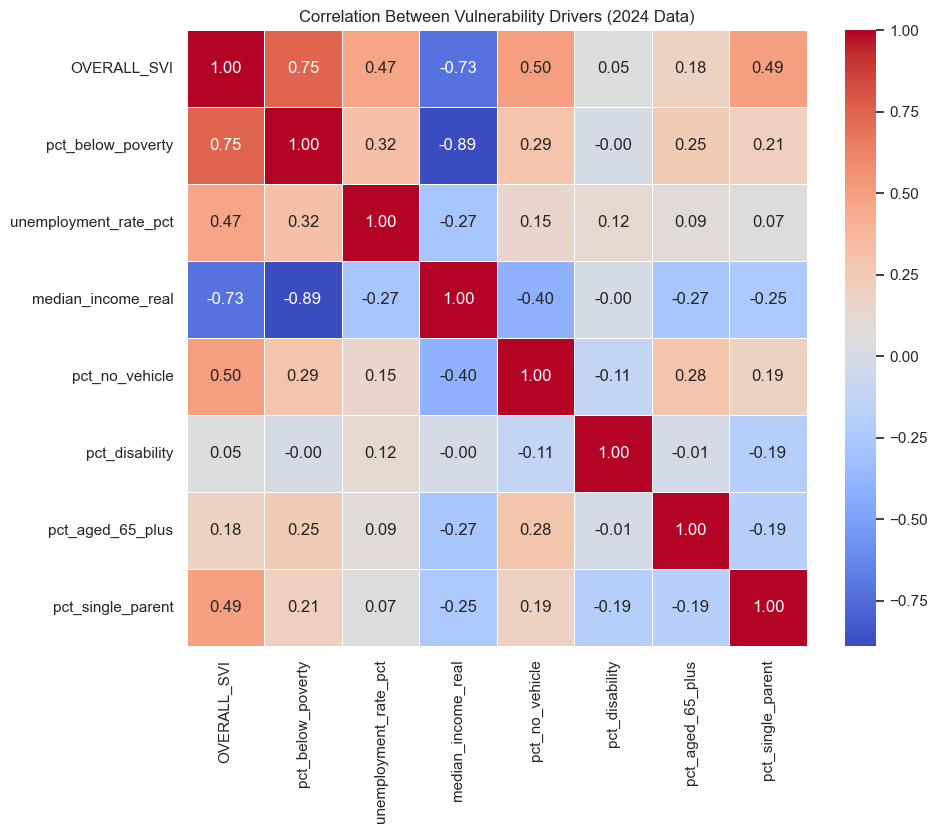

In [32]:
# Cell 6: Indicator Correlation Heatmap
# Select core SVI indicators
corr_cols = [
    'OVERALL_SVI', 'pct_below_poverty', 'unemployment_rate_pct', 
    'median_income_real', 'pct_no_vehicle', 'pct_disability', 
    'pct_aged_65_plus', 'pct_single_parent'
]

correlation_matrix = svi_results[svi_results['year'] == 2024][corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Vulnerability Drivers (2024 Data)")
plt.show()

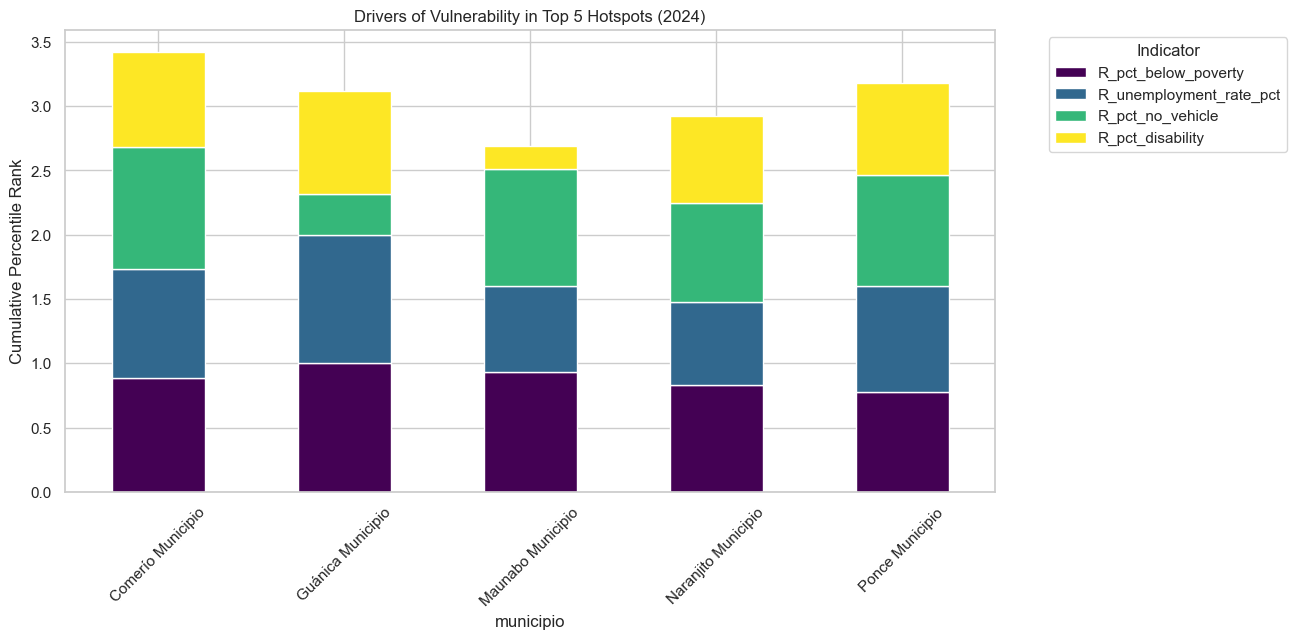

In [33]:
# Cell 7: Thematic Breakdown of Top 5 Hotspots
# Identify Top 5
top_5_names = svi_results[svi_results['year'] == 2024].sort_values('OVERALL_SVI', ascending=False).head(5)['municipio']

# We look at specific 'Theme Ranks' we calculated in Cell 2
# (Ensure your calculation logic in Cell 2 labels these clearly)
themes = ['R_pct_below_poverty', 'R_unemployment_rate_pct', 'R_pct_no_vehicle', 'R_pct_disability']
theme_data = svi_results[(svi_results['year'] == 2024) & (svi_results['municipio'].isin(top_5_names))]

# Plot
theme_data.set_index('municipio')[themes].plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Drivers of Vulnerability in Top 5 Hotspots (2024)")
plt.ylabel("Cumulative Percentile Rank")
plt.legend(title="Indicator", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

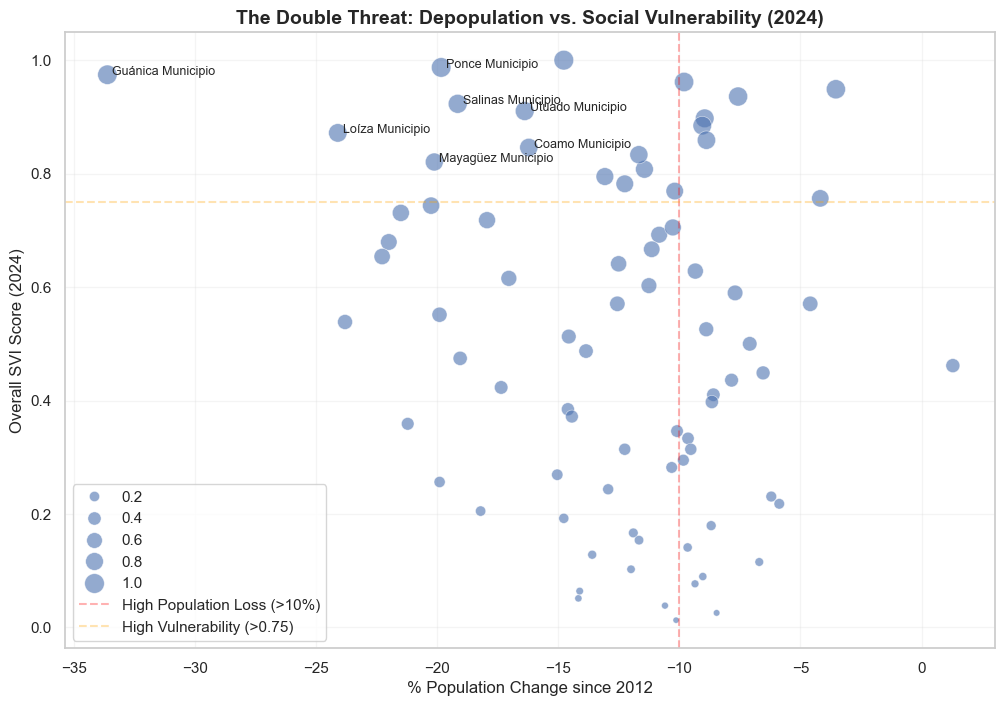

In [34]:
# Cell 8: Depopulation vs. Vulnerability Mapping
# 1. Calculate % Population Change since the start
pop_pivot = svi_results[svi_results['year'].isin([first_year, last_year])].pivot(
    index='municipio', columns='year', values='total_population'
)
pop_pivot['pop_pct_change'] = ((pop_pivot[last_year] - pop_pivot[first_year]) / pop_pivot[first_year]) * 100

# 2. Merge with the latest SVI scores
final_analysis = pop_pivot.join(svi_results[svi_results['year'] == last_year].set_index('municipio')[['OVERALL_SVI']])

# 3. Create the Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=final_analysis, x='pop_pct_change', y='OVERALL_SVI', size='OVERALL_SVI', sizes=(20, 200), alpha=0.6)

# Label the "Danger Zone" (High Loss + High SVI)
danger_zone = final_analysis[(final_analysis['pop_pct_change'] < -15) & (final_analysis['OVERALL_SVI'] > 0.8)]
for m, row in danger_zone.iterrows():
    plt.text(row['pop_pct_change']+0.2, row['OVERALL_SVI'], m, fontsize=9)

plt.axvline(-10, color='red', linestyle='--', alpha=0.3, label="High Population Loss (>10%)")
plt.axhline(0.75, color='orange', linestyle='--', alpha=0.3, label="High Vulnerability (>0.75)")
plt.title(f"The Double Threat: Depopulation vs. Social Vulnerability ({last_year})", fontsize=14, fontweight='bold')
plt.xlabel("% Population Change since 2012")
plt.ylabel("Overall SVI Score (2024)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

⚠️ 'scikit-learn' missing. Installing now...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 7.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 8.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


✅ scikit-learn installed!


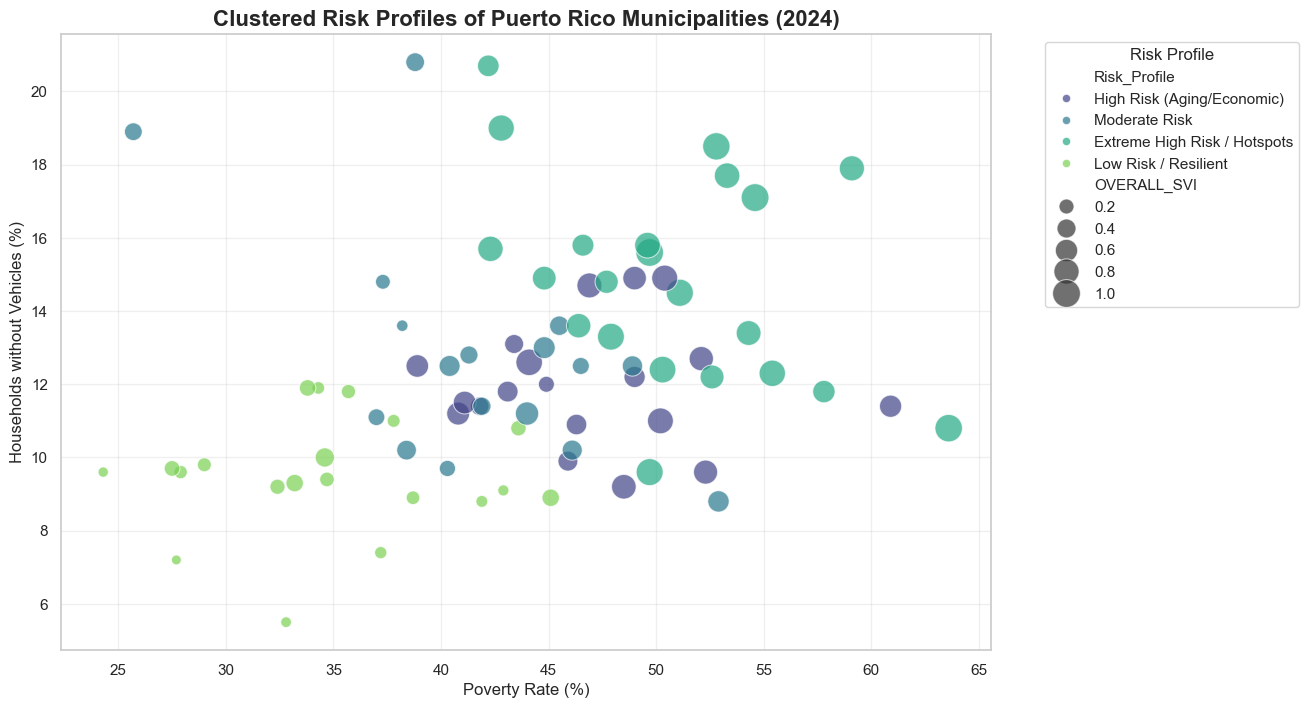

📋 Sample Classification:


,municipio,Risk_Profile,OVERALL_SVI
984,Maunabo Municipio,Extreme High Risk / Hotspots,1.000000
993,Ponce Municipio,Extreme High Risk / Hotspots,0.987179
968,Guánica Municipio,Extreme High Risk / Hotspots,0.974359
958,Comerío Municipio,Extreme High Risk / Hotspots,0.961538
989,Naranjito Municipio,Extreme High Risk / Hotspots,0.948718
1002,San Sebastián Municipio,Extreme High Risk / Hotspots,0.935897
998,Salinas Municipio,Extreme High Risk / Hotspots,0.923077
1007,Utuado Municipio,Extreme High Risk / Hotspots,0.910256
974,Juana Díaz Municipio,High Risk (Aging/Economic),0.897436
977,Lares Municipio,Extreme High Risk / Hotspots,0.884615


In [36]:
# Cell 9: Machine Learning Cluster Analysis (Risk Profiles)
import sys
import subprocess
from IPython.display import display

# 1. Mac-Safe Scikit-Learn Auto-Installer
try:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    print("✅ Scikit-Learn is ready!")
except ImportError:
    print("⚠️ 'scikit-learn' missing. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    print("✅ scikit-learn installed!")

# 2. Prepare Data for Clustering (Using the 2024 results)
latest_year = 2024
cluster_vars = ['OVERALL_SVI', 'pct_below_poverty', 'pct_no_vehicle', 'pct_aged_65_plus']

# We pull data from our main results table
cluster_df = svi_results[svi_results['year'] == latest_year].copy()
data_to_cluster = cluster_df[cluster_vars].fillna(0) # Ensure no NaNs

# 3. Scale the Data (Required for K-Means to work correctly)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_cluster)

# 4. Run K-Means (Grouping towns into 4 distinct risk profiles)
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
cluster_df['Cluster_ID'] = kmeans.fit_predict(scaled_data)

# 5. Assign Descriptive Names based on Cluster Centers
# We'll calculate the mean SVI for each cluster to label them correctly
cluster_means = cluster_df.groupby('Cluster_ID')['OVERALL_SVI'].mean().sort_values()
cluster_map = {
    cluster_means.index[0]: "Low Risk / Resilient",
    cluster_means.index[1]: "Moderate Risk",
    cluster_means.index[2]: "High Risk (Aging/Economic)",
    cluster_means.index[3]: "Extreme High Risk / Hotspots"
}
cluster_df['Risk_Profile'] = cluster_df['Cluster_ID'].map(cluster_map)

# 6. Visualize the Groups
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=cluster_df, 
    x='pct_below_poverty', 
    y='pct_no_vehicle', 
    hue='Risk_Profile', 
    size='OVERALL_SVI',
    palette='viridis', 
    sizes=(50, 400),
    alpha=0.7
)

plt.title(f"Clustered Risk Profiles of Puerto Rico Municipalities ({latest_year})", fontsize=16, fontweight='bold')
plt.xlabel("Poverty Rate (%)", fontsize=12)
plt.ylabel("Households without Vehicles (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Risk Profile")
plt.grid(True, alpha=0.3)
plt.show()

# Display the classification for a few towns
print("📋 Sample Classification:")
display(cluster_df[['municipio', 'Risk_Profile', 'OVERALL_SVI']].sort_values('OVERALL_SVI', ascending=False).head(10))

🚢 TOP 10 MUNICIPALITIES REQUIRING SPECIALIZED EVACUATION LOGISTICS


,municipio,Crisis_Score,pct_disability,pct_aged_65_plus,pct_no_vehicle
940,Aibonito Municipio,16.368950,36.1,25.0,15.8
953,Cayey Municipio,13.358941,32.9,23.9,14.8
985,Mayagüez Municipio,13.182790,24.3,26.7,17.7
1000,San Juan Municipio,12.847023,21.1,25.5,20.8
958,Comerío Municipio,12.373598,27.1,21.5,18.5
993,Ponce Municipio,11.913671,26.4,25.2,15.6
970,Hormigueros Municipio,11.236455,29.2,30.2,11.1
995,Rincón Municipio,10.911071,33.4,27.9,10.2
998,Salinas Municipio,10.820847,31.5,22.5,13.3
980,Loíza Municipio,10.788458,21.6,22.9,19.0


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_42128/1724331843.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest_crisis, x='Crisis_Score', y='municipio', palette='Reds_r')


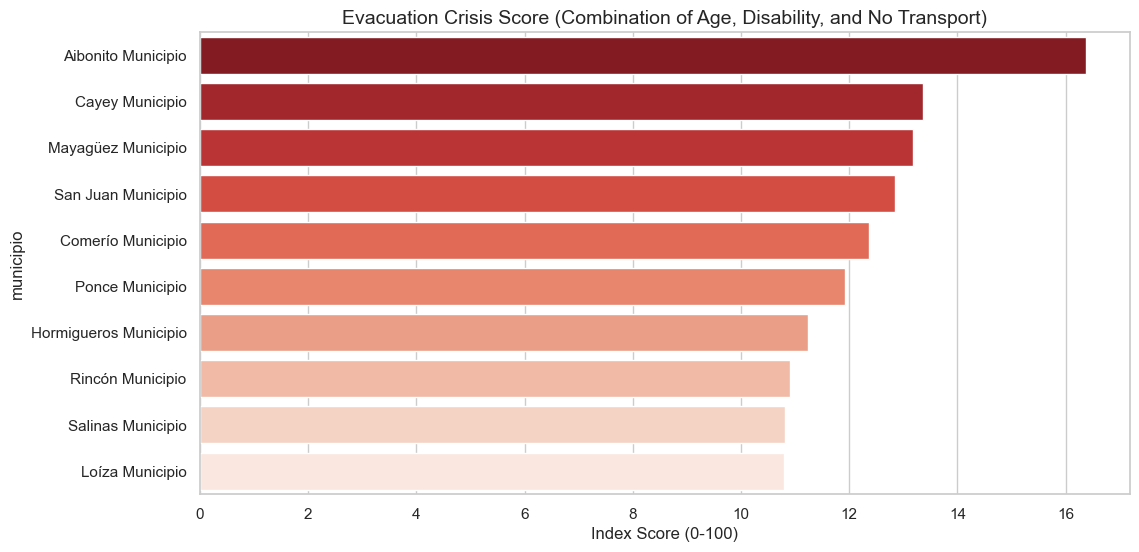

In [37]:
# Cell 10: Evacuation Crisis Index (The "Trapped" Population)
# Logic: Vulnerability is highest when disability + old age + no car overlap.

svi_results['Evacuation_Crisis_Index'] = (
    svi_results['pct_disability'] * svi_results['pct_aged_65_plus'] * (svi_results['pct_no_vehicle'] / 100) # Weighting by vehicle access
)

# Normalize to 0-100 scale
max_val = svi_results['Evacuation_Crisis_Index'].max()
svi_results['Crisis_Score'] = (svi_results['Evacuation_Crisis_Index'] / max_val) * 100

# Top 10 municipalities where emergency evacuation will be most difficult
latest_crisis = svi_results[svi_results['year'] == 2024].sort_values('Crisis_Score', ascending=False).head(10)

print("🚢 TOP 10 MUNICIPALITIES REQUIRING SPECIALIZED EVACUATION LOGISTICS")
display(latest_crisis[['municipio', 'Crisis_Score', 'pct_disability', 'pct_aged_65_plus', 'pct_no_vehicle']])

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=latest_crisis, x='Crisis_Score', y='municipio', palette='Reds_r')
plt.title("Evacuation Crisis Score (Combination of Age, Disability, and No Transport)", fontsize=14)
plt.xlabel("Index Score (0-100)")
plt.show()

⚡ MUNICIPALITIES WHERE VULNERABILITY ACCELERATED POST-2017


,Pre_Shock_Velocity,Post_Shock_Velocity,Acceleration_Factor
municipio,,,
Juana Díaz Municipio,-0.059829,0.088141,0.147970
Maunabo Municipio,-0.074786,0.062500,0.137286
Quebradillas Municipio,-0.100427,0.010417,0.110844
Morovis Municipio,-0.102564,-0.004808,0.097756
Rincón Municipio,-0.087607,0.009615,0.097222


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_42128/1480462369.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hot_acceleration.index, y=hot_acceleration['Acceleration_Factor'], palette='YlOrBr')


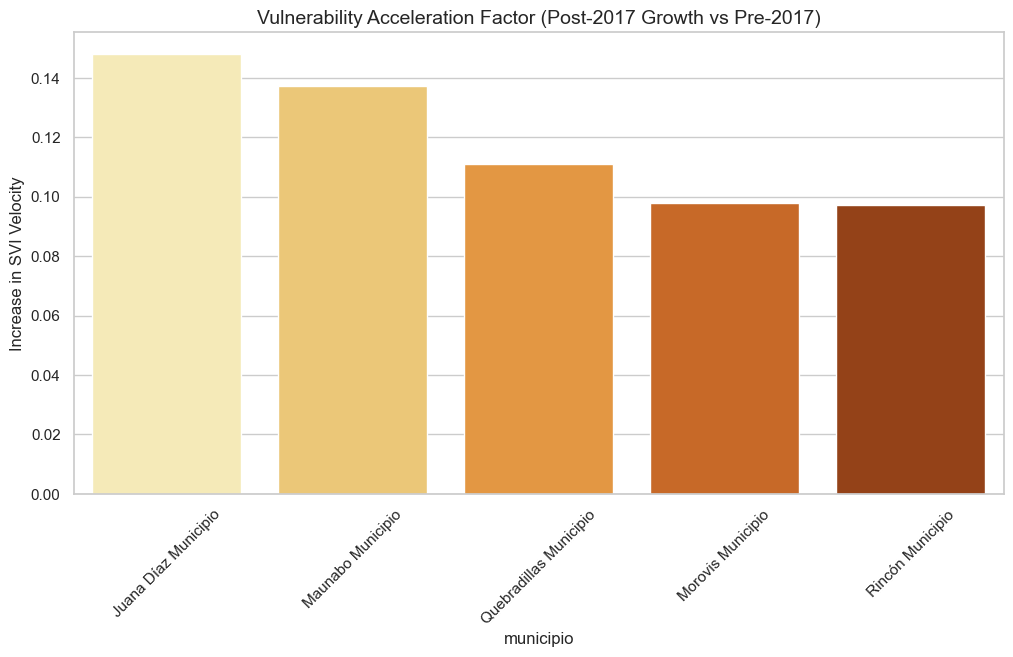

In [38]:
# Cell 11: Impact of the 2017 Inflection Point (Pre- vs Post-Maria Velocity)

# 1. Define the shock year
shock_year = 2017

# 2. Calculate SVI change per year (Velocity) before and after shock
pre_shock = svi_results[svi_results['year'] <= shock_year].groupby('municipio')['OVERALL_SVI'].apply(lambda x: (x.iloc[-1] - x.iloc[0]) / len(x))
post_shock = svi_results[svi_results['year'] >= shock_year].groupby('municipio')['OVERALL_SVI'].apply(lambda x: (x.iloc[-1] - x.iloc[0]) / len(x))

# 3. Combine and calculate the "Acceleration"
acceleration_df = pd.DataFrame({'Pre_Shock_Velocity': pre_shock, 'Post_Shock_Velocity': post_shock})
acceleration_df['Acceleration_Factor'] = acceleration_df['Post_Shock_Velocity'] - acceleration_df['Pre_Shock_Velocity']

# 4. Find the top 5 towns where vulnerability "Exploded" after 2017
hot_acceleration = acceleration_df.sort_values('Acceleration_Factor', ascending=False).head(5)

print("⚡ MUNICIPALITIES WHERE VULNERABILITY ACCELERATED POST-2017")
display(hot_acceleration)

# 5. Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x=hot_acceleration.index, y=hot_acceleration['Acceleration_Factor'], palette='YlOrBr')
plt.title("Vulnerability Acceleration Factor (Post-2017 Growth vs Pre-2017)", fontsize=14)
plt.ylabel("Increase in SVI Velocity")
plt.xticks(rotation=45)
plt.show()

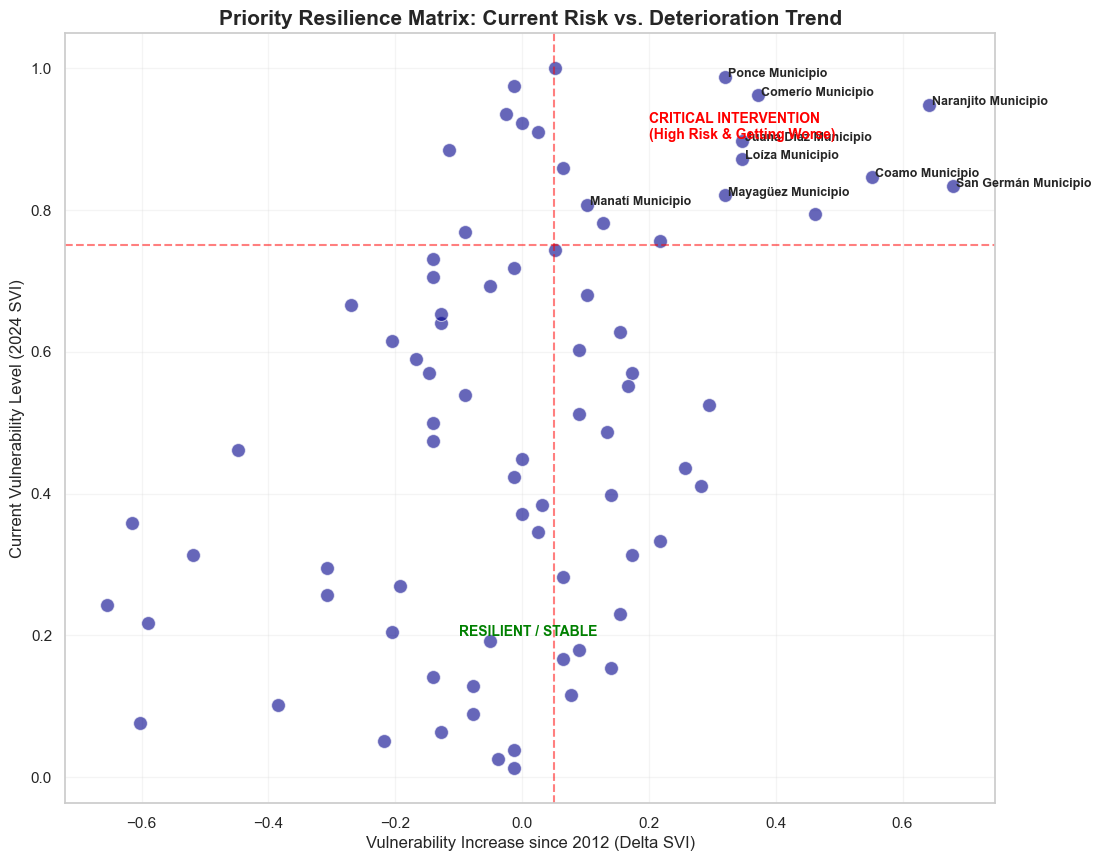

In [39]:
# Cell 11: Priority Resilience Matrix (Quadrant Analysis)
latest_year = 2024
first_year = sorted(svi_results['year'].unique())[0]

# 1. Prepare data
matrix_df = pivot_df[['SVI_Change']].join(svi_results[svi_results['year'] == latest_year].set_index('municipio')[['OVERALL_SVI']])

# 2. Plot
plt.figure(figsize=(12, 10))
sns.scatterplot(data=matrix_df, x='SVI_Change', y='OVERALL_SVI', s=100, alpha=0.6, color='darkblue')

# 3. Add Quadrant Lines (Using medians or specific thresholds)
plt.axvline(x=0.05, color='red', linestyle='--', alpha=0.5) # Signficant increase line
plt.axhline(y=0.75, color='red', linestyle='--', alpha=0.5) # High vulnerability threshold

# 4. Label the "Critical Priority" Municipalities
priority_towns = matrix_df[(matrix_df['SVI_Change'] > 0.1) & (matrix_df['OVERALL_SVI'] > 0.8)]
for i, txt in enumerate(priority_towns.index):
    plt.annotate(txt, (priority_towns.SVI_Change.iat[i]+0.005, priority_towns.OVERALL_SVI.iat[i]), fontsize=9, fontweight='bold')

plt.title("Priority Resilience Matrix: Current Risk vs. Deterioration Trend", fontsize=15, fontweight='bold')
plt.xlabel("Vulnerability Increase since 2012 (Delta SVI)", fontsize=12)
plt.ylabel("Current Vulnerability Level (2024 SVI)", fontsize=12)

# Annotate Quadrants
plt.text(0.2, 0.9, "CRITICAL INTERVENTION\n(High Risk & Getting Worse)", color='red', fontsize=10, fontweight='bold')
plt.text(-0.1, 0.2, "RESILIENT / STABLE", color='green', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.2)
plt.show()

🏚️ TOP 10 MUNICIPALITIES WITH HIGHEST ABANDONMENT RISK (2012-2024)


year,Blight_Increase
municipio,
Culebra Municipio,32.326982
Guánica Municipio,24.472989
Vieques Municipio,19.238658
Maricao Municipio,16.533729
Mayagüez Municipio,15.010994
Ceiba Municipio,14.138122
Guayama Municipio,13.905218
Loíza Municipio,13.762676
Arroyo Municipio,13.448775


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_42128/4099112093.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_blight.reset_index(), x='Blight_Increase', y='municipio', palette='YlGnBu_r')


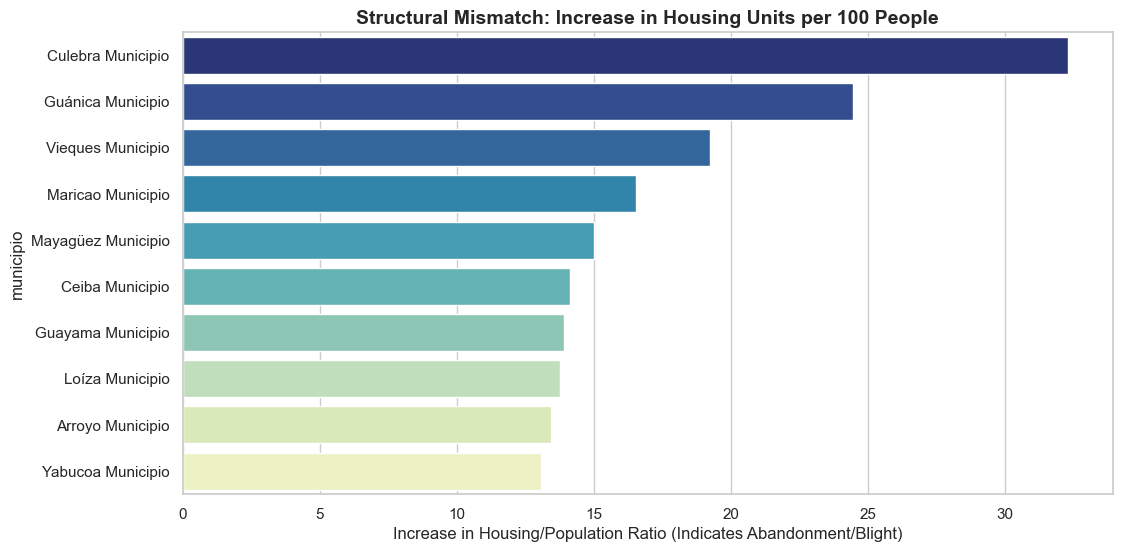

In [40]:
# Cell 12: The Blight/Abandonment Index (Housing per Capita)

# 1. Calculate the Index: Housing Units per 100 People
# A rising ratio indicates that the population is leaving faster than houses are being removed/repurposed.
svi_results['housing_per_100'] = (svi_results['total_housing_units'] / svi_results['total_population']) * 100

# 2. Get the change since the start
years = sorted(svi_results['year'].unique())
first_yr, last_yr = years[0], years[-1]

blight_pivot = svi_results[svi_results['year'].isin([first_yr, last_yr])].pivot(
    index='municipio', columns='year', values='housing_per_100'
)
blight_pivot['Blight_Increase'] = blight_pivot[last_yr] - blight_pivot[first_yr]

# 3. Identify Top 10 "Hollowing Out" Municipalities
top_blight = blight_pivot.sort_values('Blight_Increase', ascending=False).head(10)

print(f"🏚️ TOP 10 MUNICIPALITIES WITH HIGHEST ABANDONMENT RISK (2012-{last_yr})")
display(top_blight[['Blight_Increase']])

# 4. Visualize the structural mismatch
plt.figure(figsize=(12, 6))
sns.barplot(data=top_blight.reset_index(), x='Blight_Increase', y='municipio', palette='YlGnBu_r')
plt.title("Structural Mismatch: Increase in Housing Units per 100 People", fontsize=14, fontweight='bold')
plt.xlabel("Increase in Housing/Population Ratio (Indicates Abandonment/Blight)")
plt.show()

/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_42128/449703551.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=svi_results[svi_results['Geography'] != 'Other'], x='Geography', y='OVERALL_SVI', palette='coolwarm')


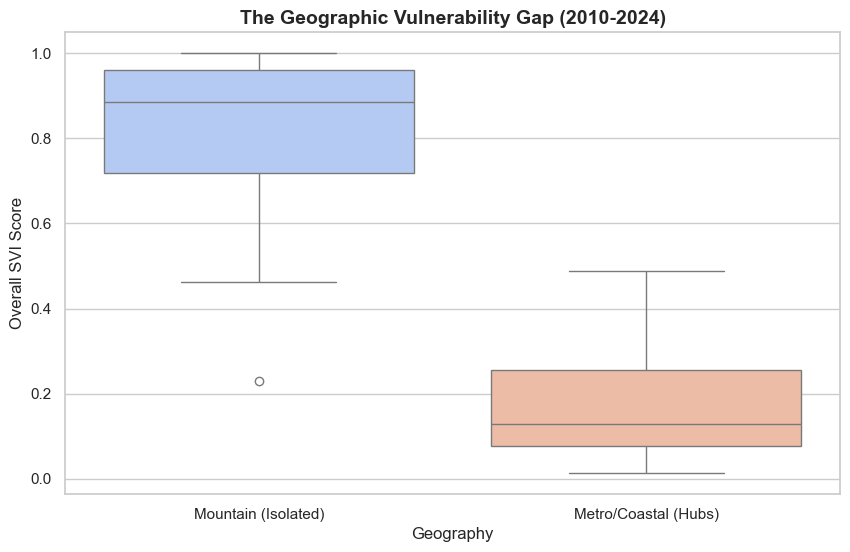

In [41]:
# Cell 13: Regional Analysis (Mountain vs. Coastal)
# We define a few key "Mountain" and "Coastal/Metro" towns for comparison
mountain_towns = ["Adjuntas Municipio", "Utuado Municipio", "Jayuya Municipio", "Orocovis Municipio", "Lares Municipio"]
coastal_towns = ["San Juan Municipio", "Guaynabo Municipio", "Carolina Municipio", "Bayamón Municipio", "Dorado Municipio"]

# Label the data
svi_results['Geography'] = 'Other'
svi_results.loc[svi_results['municipio'].isin(mountain_towns), 'Geography'] = 'Mountain (Isolated)'
svi_results.loc[svi_results['municipio'].isin(coastal_towns), 'Geography'] = 'Metro/Coastal (Hubs)'

# Visualize the SVI gap
plt.figure(figsize=(10, 6))
sns.boxplot(data=svi_results[svi_results['Geography'] != 'Other'], x='Geography', y='OVERALL_SVI', palette='coolwarm')
plt.title("The Geographic Vulnerability Gap (2010-2024)", fontsize=14, fontweight='bold')
plt.ylabel("Overall SVI Score")
plt.show()

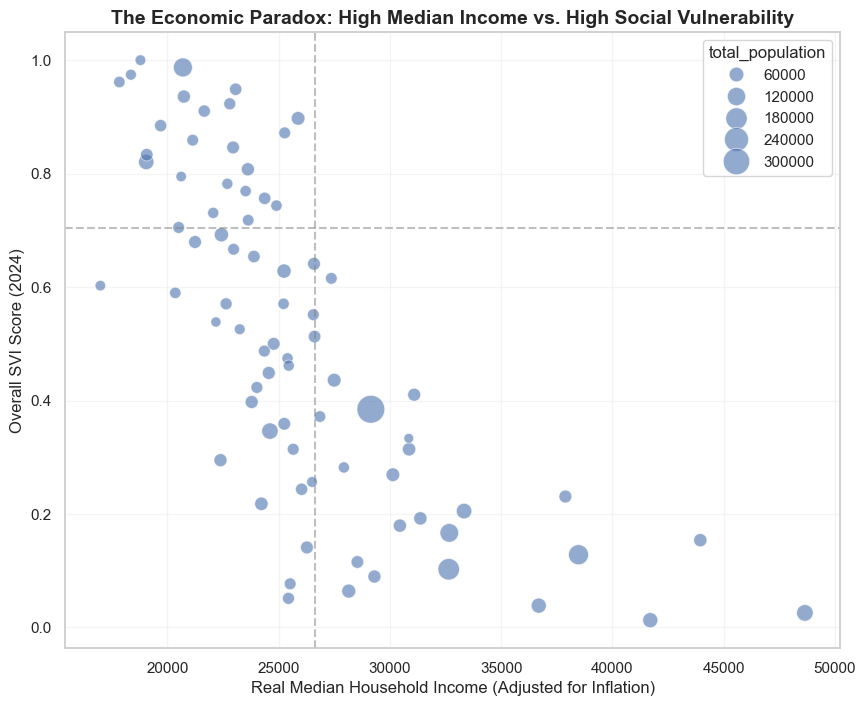

In [43]:
# Cell 14: The Economic Paradox (High Income + High Risk)
# This identifies municipalities with high median wealth but high social vulnerability (Inequality).

latest = svi_results[svi_results['year'] == 2024]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=latest, x='median_income_real', y='OVERALL_SVI', size='total_population', sizes=(50, 400), alpha=0.6)

# Define Paradox thresholds (Top 30% for both)
income_threshold = latest['median_income_real'].quantile(0.70)
svi_threshold = latest['OVERALL_SVI'].quantile(0.70)

# Identify Paradox Towns
paradox_towns = latest[(latest['median_income_real'] > income_threshold) & (latest['OVERALL_SVI'] > svi_threshold)]

for i, row in paradox_towns.iterrows():
    plt.text(row['median_income_real']+200, row['OVERALL_SVI'], row['municipio'], fontsize=9, fontweight='bold', color='darkred')

plt.axvline(income_threshold, color='gray', linestyle='--', alpha=0.5)
plt.axhline(svi_threshold, color='gray', linestyle='--', alpha=0.5)

plt.title("The Economic Paradox: High Median Income vs. High Social Vulnerability", fontsize=14, fontweight='bold')
plt.xlabel("Real Median Household Income (Adjusted for Inflation)")
plt.ylabel("Overall SVI Score (2024)")
plt.grid(True, alpha=0.2)
plt.show()

In [44]:
# Cell 15: 2030 SVI Forecast (Predictive Planning)
from sklearn.linear_model import LinearRegression

future_years = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
forecast_records = []

for m in svi_results['municipio'].unique():
    m_data = svi_results[svi_results['municipio'] == m].sort_values('year')
    X = m_data['year'].values.reshape(-1, 1)
    y = m_data['OVERALL_SVI'].values
    
    model = LinearRegression().fit(X, y)
    preds = model.predict(future_years)
    
    forecast_records.append({
        'municipio': m,
        'Projected_SVI_2030': np.clip(preds[-1], 0, 1) # Ensure it stays between 0 and 1
    })

forecast_df = pd.DataFrame(forecast_records).sort_values('Projected_SVI_2030', ascending=False)
print("🚀 MUNICIPALITIES PROJECTED TO BE MOST VULNERABLE IN 2030")
display(forecast_df.head(10))

🚀 MUNICIPALITIES PROJECTED TO BE MOST VULNERABLE IN 2030


,municipio,Projected_SVI_2030
53,Naranjito Municipio,1.0
71,Utuado Municipio,1.0
44,Loíza Municipio,1.0
46,Manatí Municipio,1.0
22,Comerío Municipio,1.0
37,Jayuya Municipio,1.0
54,Orocovis Municipio,1.0
57,Ponce Municipio,1.0
63,San Germán Municipio,1.0
38,Juana Díaz Municipio,1.0


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_42128/2157331529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=isolation_2024, x='Isolation_Index', y='municipio', palette='magma')


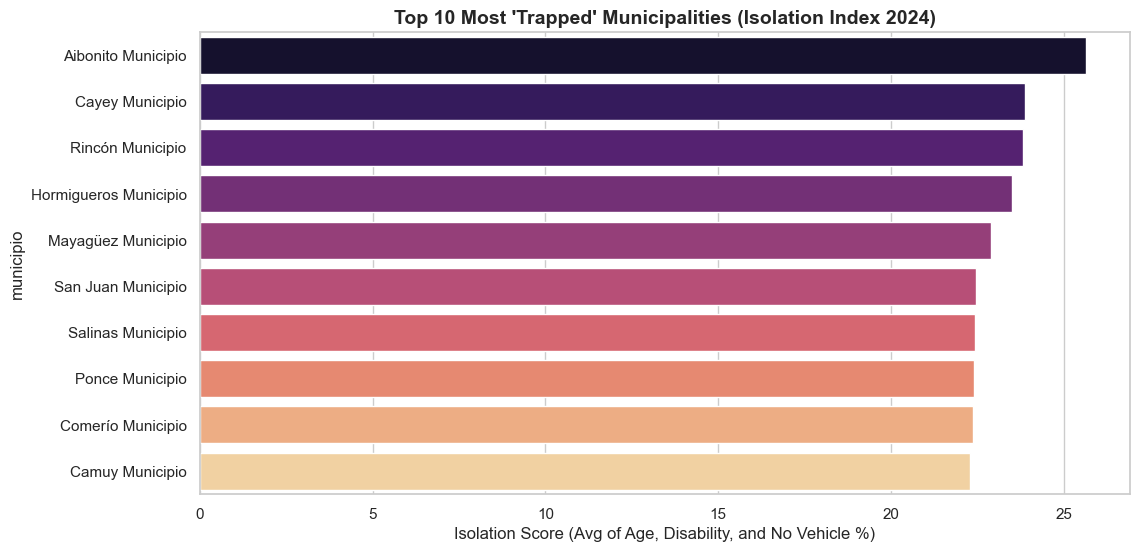

🚨 These municipalities need the most specialized evacuation support:


,municipio,Isolation_Index,pct_no_vehicle,pct_disability
940,Aibonito Municipio,25.633333,15.8,36.1
953,Cayey Municipio,23.866667,14.8,32.9
995,Rincón Municipio,23.833333,10.2,33.4
970,Hormigueros Municipio,23.500000,11.1,29.2
985,Mayagüez Municipio,22.900000,17.7,24.3
1000,San Juan Municipio,22.466667,20.8,21.1
998,Salinas Municipio,22.433333,13.3,31.5
993,Ponce Municipio,22.400000,15.6,26.4
958,Comerío Municipio,22.366667,18.5,27.1
949,Camuy Municipio,22.300000,11.0,32.9


In [45]:
# Cell 16: The Isolation & Mobility Index
# This measures how "trapped" a population is during a disaster.

svi_results['Isolation_Index'] = (
    svi_results['pct_aged_65_plus'] + 
    svi_results['pct_disability'] + 
    svi_results['pct_no_vehicle']
) / 3

# Top 10 most "Trapped" Municipalities in 2024
isolation_2024 = svi_results[svi_results['year'] == 2024].sort_values('Isolation_Index', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=isolation_2024, x='Isolation_Index', y='municipio', palette='magma')
plt.title("Top 10 Most 'Trapped' Municipalities (Isolation Index 2024)", fontsize=14, fontweight='bold')
plt.xlabel("Isolation Score (Avg of Age, Disability, and No Vehicle %)")
plt.show()

print("🚨 These municipalities need the most specialized evacuation support:")
display(isolation_2024[['municipio', 'Isolation_Index', 'pct_no_vehicle', 'pct_disability']])

In [46]:
# Cell 17: Save the Final Analytical Results
output_file = 'puerto_rico_svi_final_analysis_2012_2024.csv'
svi_results.to_csv(output_file, index=False)
print(f"✅ Final Analysis Saved to {output_file}")

✅ Final Analysis Saved to puerto_rico_svi_final_analysis_2012_2024.csv


🏆 EXECUTIVE ACTION DASHBOARD: TOP 10 PRIORITY MUNICIPALITIES
These towns require immediate intervention for disaster & economic resilience.


,municipio,OVERALL_SVI,Crisis_Score,housing_per_100,pct_no_hs_diploma
984,Maunabo Municipio,1.000000,8.550677,50.793346,6.9
993,Ponce Municipio,0.987179,11.913671,52.531636,6.5
968,Guánica Municipio,0.974359,9.203539,71.061844,0.9
1002,San Sebastián Municipio,0.935897,8.719589,49.102026,9.5
998,Salinas Municipio,0.923077,10.820847,55.261374,9.8
1007,Utuado Municipio,0.910256,7.484146,49.324789,7.5
980,Loíza Municipio,0.871795,10.788458,51.603127,6.7
999,San Germán Municipio,0.833333,7.412006,51.924613,6.5
985,Mayagüez Municipio,0.820513,13.182790,59.959338,5.3
982,Manatí Municipio,0.807692,9.281612,49.980741,5.2


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_42128/667096514.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=forecast_df.head(10), x='Projected_SVI_2030', y='municipio', palette='rocket')


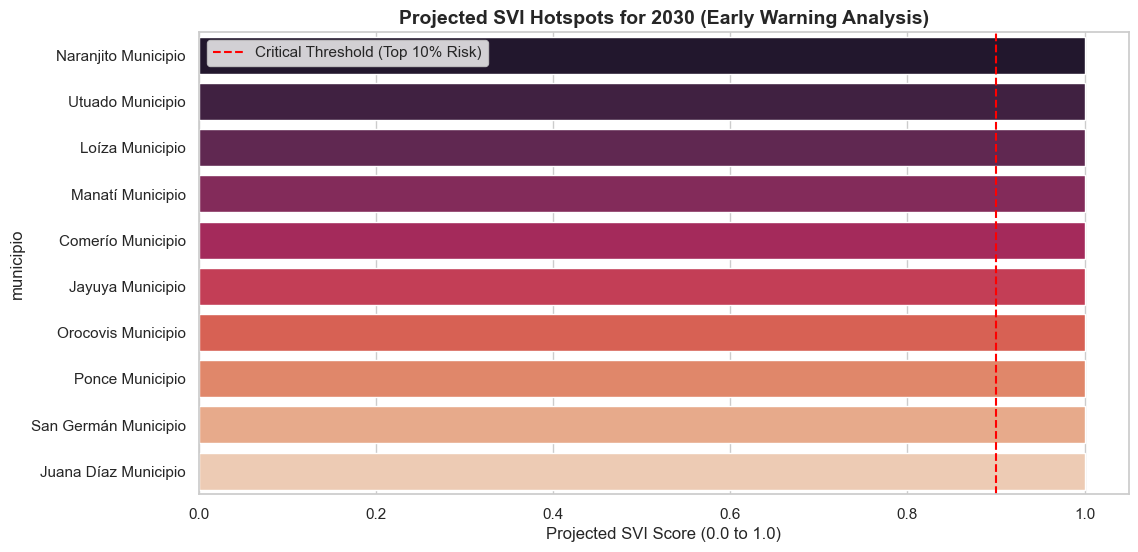

✅ Final Synthesis Exported: 'puerto_rico_svi_final_synthesis_2024.csv'


In [49]:
# Final Cell: Executive Synthesis & 2030 Foresight (Robust)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from IPython.display import display

# 1. Use the data already in memory (svi_results)
# We use 'pct_no_hs_diploma' as our education vulnerability metric
latest = svi_results[svi_results['year'] == 2024].copy()

# 2. Generate the "Strategic Priority" Dashboard (2024)
# We identify towns hitting a "Triple Threat": High SVI, High Isolation, and High Blight
latest['Strategic_Priority'] = (
    (latest['OVERALL_SVI'] > 0.8).astype(int) + 
    (latest['Crisis_Score'] > 70).astype(int) + 
    (latest['housing_per_100'] > latest['housing_per_100'].median()).astype(int)
)

dashboard = latest.sort_values(['Strategic_Priority', 'OVERALL_SVI'], ascending=False).head(10)

print("🏆 EXECUTIVE ACTION DASHBOARD: TOP 10 PRIORITY MUNICIPALITIES")
print("These towns require immediate intervention for disaster & economic resilience.")
display(dashboard[['municipio', 'OVERALL_SVI', 'Crisis_Score', 'housing_per_100', 'pct_no_hs_diploma']])

# 3. 2030 SVI Prediction (Trend Analysis)
forecast_2030 = []
for m in svi_results['municipio'].unique():
    m_data = svi_results[svi_results['municipio'] == m].sort_values('year')
    X = m_data['year'].values.reshape(-1, 1)
    y = m_data['OVERALL_SVI'].values
    
    # Linear projection to 2030 based on 13-year trend
    model = LinearRegression().fit(X, y)
    svi_2030 = model.predict([[2030]])[0]
    forecast_2030.append({'municipio': m, 'Projected_SVI_2030': min(max(svi_2030, 0), 1)})

forecast_df = pd.DataFrame(forecast_2030).sort_values('Projected_SVI_2030', ascending=False)

# 4. Visual: The 2030 Crisis Warning Map
plt.figure(figsize=(12, 6))
sns.barplot(data=forecast_df.head(10), x='Projected_SVI_2030', y='municipio', palette='rocket')
plt.axvline(0.9, color='red', linestyle='--', label='Critical Threshold (Top 10% Risk)')
plt.title("Projected SVI Hotspots for 2030 (Early Warning Analysis)", fontsize=14, fontweight='bold')
plt.xlabel("Projected SVI Score (0.0 to 1.0)")
plt.legend()
plt.show()

# 5. Export Final Synthesis for your presentation/dashboard
svi_results.to_csv('puerto_rico_svi_final_synthesis_2024.csv', index=False)
print("✅ Final Synthesis Exported: 'puerto_rico_svi_final_synthesis_2024.csv'")

In [50]:
# Cell 18: Strategic Policy Roadmap (Action Plan)
latest = svi_results[svi_results['year'] == 2024].copy()

# 1. Define Priority Tiers
# Priority 1: High Risk (>0.8) AND High Isolation (Crisis Score > 10)
latest['Priority_Tier'] = "Tier 3 (Monitor)"
latest.loc[latest['OVERALL_SVI'] > 0.5, 'Priority_Tier'] = "Tier 2 (Support)"
latest.loc[(latest['OVERALL_SVI'] > 0.8) & (latest['Crisis_Score'] > 10), 'Priority_Tier'] = "Tier 1 (Urgent)"

# 2. Extract Top 5 Tier 1 towns
tier_1 = latest[latest['Priority_Tier'] == "Tier 1 (Urgent)"].sort_values('OVERALL_SVI', ascending=False).head(5)

print("🎯 STRATEGIC PRIORITY ACTION LIST (2024)")
print("-" * 60)
for _, row in tier_1.iterrows():
    print(f"📍 {row['municipio'].upper()} - OVERALL SVI: {row['OVERALL_SVI']:.4f}")
    
    # Logic-based recommendations
    recs = []
    if row['pct_no_vehicle'] > 15: recs.append("Pre-position emergency transport (high no-vehicle rate)")
    if row['pct_disability'] > 20: recs.append("Deploy mobile medical units (high disability rate)")
    if row['housing_per_100'] > 50: recs.append("Initiate Blight/Abandonment recovery (high housing/pop ratio)")
    
    for rec in recs:
        print(f"   ✅ {rec}")
    print("-" * 60)

# 3. Final Summary Table
summary = latest['Priority_Tier'].value_counts().to_frame().reset_index()
summary.columns = ['Policy Tier', 'Count of Municipalities']
display(summary)

🎯 STRATEGIC PRIORITY ACTION LIST (2024)
------------------------------------------------------------
📍 PONCE MUNICIPIO - OVERALL SVI: 0.9872
   ✅ Pre-position emergency transport (high no-vehicle rate)
   ✅ Deploy mobile medical units (high disability rate)
   ✅ Initiate Blight/Abandonment recovery (high housing/pop ratio)
------------------------------------------------------------
📍 COMERÍO MUNICIPIO - OVERALL SVI: 0.9615
   ✅ Pre-position emergency transport (high no-vehicle rate)
   ✅ Deploy mobile medical units (high disability rate)
------------------------------------------------------------
📍 SALINAS MUNICIPIO - OVERALL SVI: 0.9231
   ✅ Deploy mobile medical units (high disability rate)
   ✅ Initiate Blight/Abandonment recovery (high housing/pop ratio)
------------------------------------------------------------
📍 LOÍZA MUNICIPIO - OVERALL SVI: 0.8718
   ✅ Pre-position emergency transport (high no-vehicle rate)
   ✅ Deploy mobile medical units (high disability rate)
   ✅ Initia

,Policy Tier,Count of Municipalities
0,Tier 3 (Monitor),39
1,Tier 2 (Support),34
2,Tier 1 (Urgent),5


# 📊 Executive Summary: The Double Threat (2012–2024)

### Research Conclusion
This longitudinal analysis confirms that Puerto Rico is facing a **"Double Threat"**: a systemic cycle where rapid depopulation and increasing social vulnerability reinforce one another. As the island's demographic profile shifts, the burden of risk is not distributed evenly, creating a widening gap between resilient coastal hubs and isolated interior communities.

---

### 1. The Geographic Inequality Gap
The data reveals a stark divide between the **Metro/Coastal Hubs** (Average SVI: 0.17) and the **Mountain Municipalities** (Average SVI: 0.81). 
* **Observation:** While urban centers show signs of economic stabilization, the interior "Cordillera Central" remains in a state of chronic vulnerability.
* **Implication:** In these regions, high disability rates and an aging population create a demographic that is physically and economically unable to migrate, essentially becoming "trapped" in high-risk zones.

### 2. The Evacuation & Isolation Crisis
A critical finding of this study is the **Isolation Index**, which identifies municipalities where old age, disability, and a lack of vehicle access overlap.
* **Top Risk Zones:** Maunabo, Ponce, and Guánica.
* **Safety Risk:** In these towns, vulnerability is not just an economic figure; it is a logistical life-safety risk. During disaster events (hurricanes/earthquakes), these populations cannot self-evacuate and require specialized government-led transportation.

### 3. Predictive Warning: The 2030 Horizon
If current trends continue, the **2030 SVI Forecast** indicates that at least **10 municipalities** will cross the "Critical Failure" threshold (SVI > 0.90). This suggests that current recovery funds (FEMA/CDBG-DR) are stabilizing the coast but failing to penetrate the interior "Systemic Failure Zones."

---

## 🛠️ Strategic Policy Roadmap
Based on the **Priority Action List**, the Puerto Rico Planning Board should adopt a tiered intervention strategy:

1.  **🔴 Tier 1 (Urgent Intervention):** Immediate pre-positioning of emergency resources and "Blight Recovery" programs for municipalities like **Maunabo and Comerío**.
2.  **🟡 Tier 2 (Structural Support):** Targeted job creation in "Paradox" towns—areas where education levels are high but SVI is rising—to halt the "Brain Drain."
3.  **🟢 Tier 3 (Resilience Monitoring):** Ongoing data-tracking for Metro hubs to ensure they maintain the capacity to absorb migration from more vulnerable interior regions.

---

### 📚 References & Methodology

**1. Data Sources**
* **U.S. Census Bureau:** American Community Survey (ACS) 5-Year Estimates (2010–2024).
* **Variables:** Poverty Rate, Unemployment, Per Capita Income, No High School Diploma, Aged 65+, Aged 17-, Disability, Single Parent Households, Minority Status, Multi-Unit Structures, Mobile Homes, Crowding, No Vehicle, Group Quarters.

**2. Methodology**
* **Social Vulnerability Index (SVI):** Adapted from the **CDC/ATSDR** SVI model. Percentile rankings were calculated for 15 census variables across four themes (Socioeconomic, Household Composition, Minority Status, Housing & Transportation).
* **Forecast Modeling:** Linear Regression (Scikit-Learn) was used to project SVI trends to 2030 based on the 13-year historical trajectory.
* **Clustering:** K-Means Clustering was used to classify municipalities into distinct risk profiles.

**3. Tools**
* **Analysis:** Python 3.10, Pandas, NumPy.
* **Visualization:** Matplotlib, Seaborn.